In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('heart.csv')

Shape: (270, 14)

Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

--- First 15 rows ---


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence



--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12

<Figure size 1200x800 with 0 Axes>

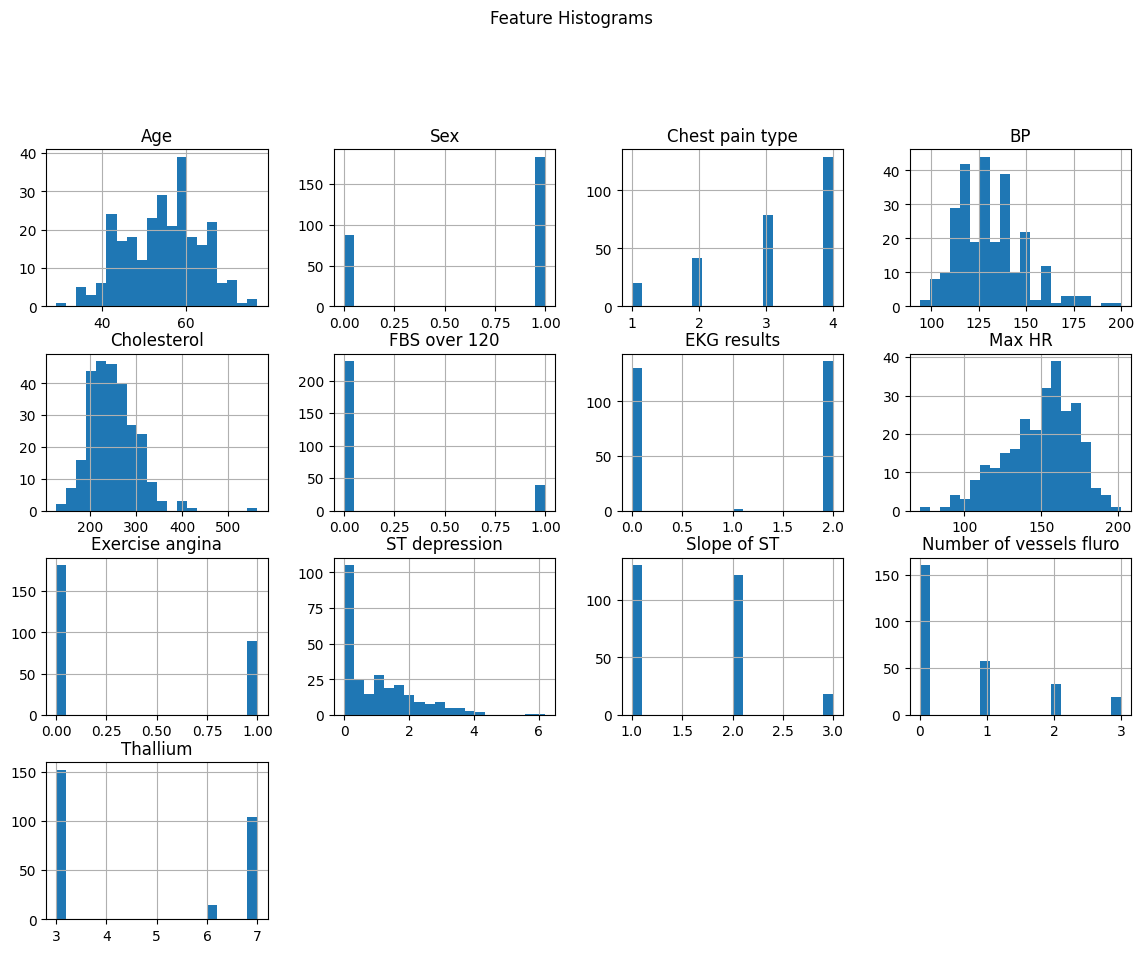

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\n--- First 15 rows ---")
display(df.head(15))

print("\n--- Info ---")
df.info()

print("\n--- Missing values ---")
print(df.isna().sum())

print("\n--- Target distribution (before encoding) ---")
print(df["Heart Disease"].value_counts())

plt.figure(figsize=(12, 8))
df.drop(columns=["Heart Disease"]).hist(bins=20, figsize=(14, 10))
plt.suptitle("Feature Histograms", y=1.02)
plt.show()

In [4]:
le = LabelEncoder()
df["Heart Disease"] = le.fit_transform(df["Heart Disease"])  # Absence/Presence -> 0/1

X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # better split for classification
)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- PCA Info ---
Original features: 13
PCA components kept: 12
Explained variance ratio sum: 0.9727


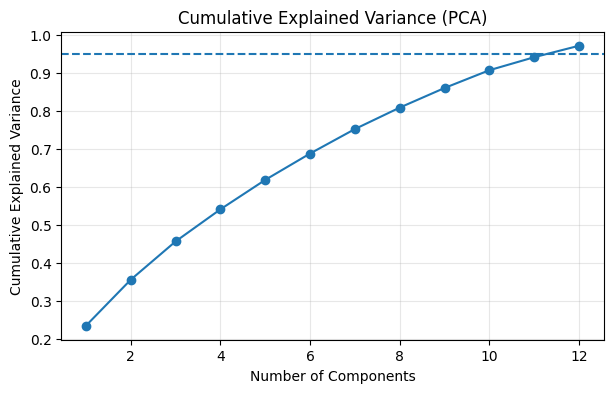

In [7]:
pca = PCA(n_components=0.95, random_state=42)  
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\n--- PCA Info ---")
print("Original features:", X_train.shape[1])
print("PCA components kept:", pca.n_components_)
print("Explained variance ratio sum:", round(pca.explained_variance_ratio_.sum(), 4))

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, linestyle="--")
plt.title("Cumulative Explained Variance (PCA)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.show()


def train_eval_plot(model_name, model, Xtr, Xte, y_train, y_test, class_names):
    model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n==================== {model_name} ====================")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return acc



==================== PCA + Naive Bayes ====================
Accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

     Absence       0.86      0.83      0.85        30
    Presence       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



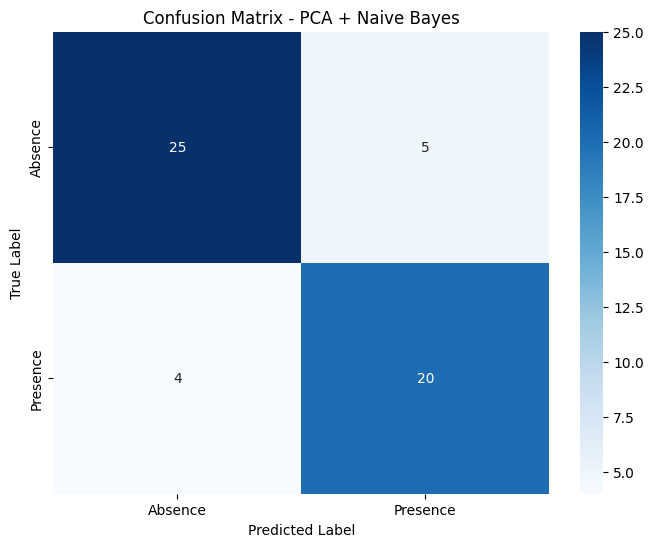


==================== PCA + SVM (RBF) ====================
Accuracy: 0.8148

Classification Report:
              precision    recall  f1-score   support

     Absence       0.86      0.80      0.83        30
    Presence       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



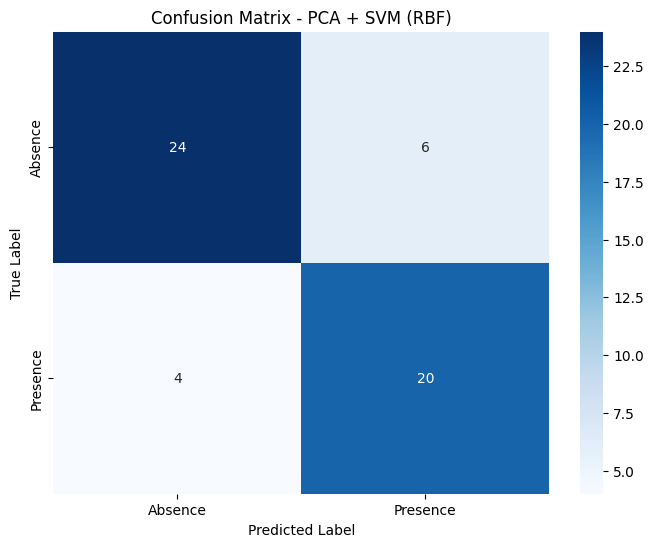


==================== PCA + Random Forest ====================
Accuracy: 0.8704

Classification Report:
              precision    recall  f1-score   support

     Absence       0.90      0.87      0.88        30
    Presence       0.84      0.88      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.87      0.87        54
weighted avg       0.87      0.87      0.87        54



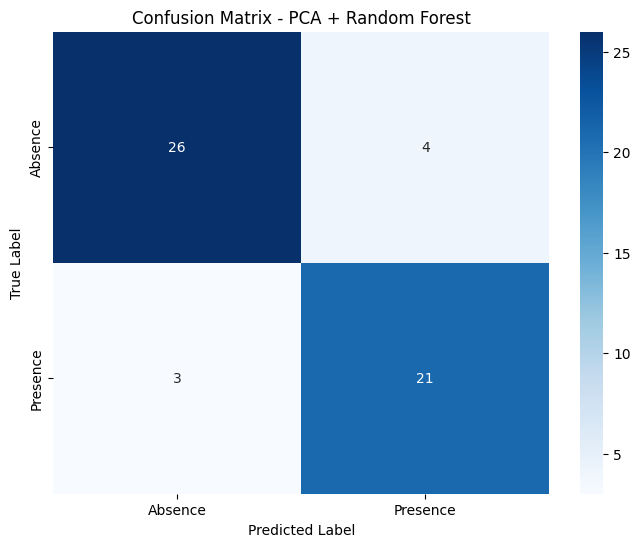

In [8]:
accuracies = {}

# (A) PCA + Naive Bayes
nb = GaussianNB()
accuracies["PCA + Naive Bayes"] = train_eval_plot(
    "PCA + Naive Bayes", nb, X_train_pca, X_test_pca, y_train, y_test, le.classes_
)

# (B) PCA + SVM (RBF)
svm = SVC(kernel="rbf", probability=True, random_state=42)
accuracies["PCA + SVM (RBF)"] = train_eval_plot(
    "PCA + SVM (RBF)", svm, X_train_pca, X_test_pca, y_train, y_test, le.classes_
)

# (C) PCA + Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
accuracies["PCA + Random Forest"] = train_eval_plot(
    "PCA + Random Forest", rf, X_train_pca, X_test_pca, y_train, y_test, le.classes_
)



=== Accuracy Comparison Table ===


,Model,Accuracy
0,PCA + Random Forest,0.870370
1,PCA + Naive Bayes,0.833333
2,PCA + SVM (RBF),0.814815


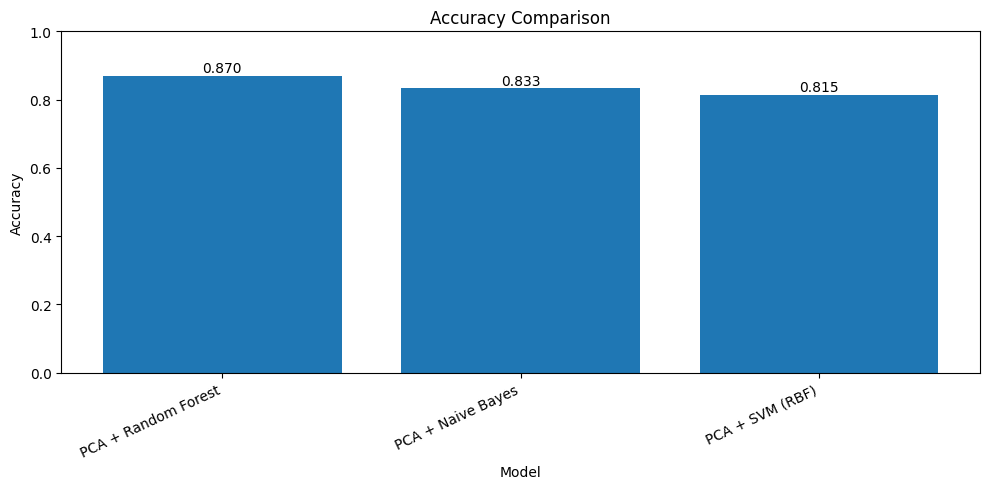

In [10]:
results_df = pd.DataFrame(
    [{"Model": k, "Accuracy": v} for k, v in accuracies.items()]
).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\n=== Accuracy Comparison Table ===")
display(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()